# Ground-truth networks for `network_sweep_final`

Draws the ground-truth network for every unique network configuration used in `network_sweep_final`, with `grn_plot_spread_v2.plot_grn`.

Panel titles follow the `grn_n6_e{edges}_pos{percent_positive}_{scenario}_rep{network_replicate}` naming convention (e.g. `grn_n6_e9_pos0_sign_ratio_rep2`).

In [1]:
import sys, os, re, glob, textwrap
import numpy as np
import matplotlib.pyplot as plt

CODE_REPO = "/home/gzu5140/Keerthana_b1042/TwINFER/code/TwINFER"
sys.path.insert(0, os.path.join(CODE_REPO, "synthetic_network_analysis"))
from grn_plot_spread_v2 import plot_grn

GT_DIR = "/home/gzu5140/Keerthana_b1042/TwINFER/input_data/network_sweep_final"
INFER_DIR = "/home/gzu5140/Keerthana_b1042/TwINFER/analysis_data/network_sweep_final/network_inference"
N_GENES = 6


In [2]:
# ---------------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------------

CONFIG_RE = re.compile(r"^e(\d+)_pos(\d+)_(density|sign_ratio|center)_rep(\d+)_rep(\d+)_")

def parse_config(fname):
    m = CONFIG_RE.match(os.path.basename(fname))
    if not m:
        return None
    e, pos, typ, netrep, simrep = m.groups()
    return dict(e=int(e), pos=int(pos), type=typ, netrep=int(netrep), simrep=int(simrep))

def nice_title(e, pos, typ, netrep):
    return f"grn_n6_e{e}_pos{pos}_{typ}_rep{netrep}"

def load_ground_truth(name):
    path = os.path.join(GT_DIR, f"{name}.txt")
    matrix = np.loadtxt(path, delimiter=",")
    return np.asarray(matrix, dtype=float)


In [3]:
# ---------------------------------------------------------------------------
# 1. Discover every unique network config in network_sweep_final
# ---------------------------------------------------------------------------

files = sorted(glob.glob(os.path.join(INFER_DIR, "*_all_results.json")))
configs = set()
for f in files:
    cfg = parse_config(f)
    if cfg is None:
        continue
    configs.add((cfg["e"], cfg["pos"], cfg["type"], cfg["netrep"]))

names = [nice_title(*key) for key in sorted(configs)]
print(f"Found {len(names)} unique network configs:")
for name in names:
    print(" ", name)


Found 15 unique network configs:
  grn_n6_e5_pos100_density_rep0
  grn_n6_e5_pos100_density_rep1
  grn_n6_e5_pos100_density_rep2
  grn_n6_e9_pos0_sign_ratio_rep0
  grn_n6_e9_pos0_sign_ratio_rep1
  grn_n6_e9_pos0_sign_ratio_rep2
  grn_n6_e9_pos50_sign_ratio_rep0
  grn_n6_e9_pos50_sign_ratio_rep1
  grn_n6_e9_pos50_sign_ratio_rep2
  grn_n6_e9_pos100_center_rep0
  grn_n6_e9_pos100_center_rep1
  grn_n6_e9_pos100_center_rep2
  grn_n6_e17_pos100_density_rep0
  grn_n6_e17_pos100_density_rep1
  grn_n6_e17_pos100_density_rep2


In [4]:
# ---------------------------------------------------------------------------
# 2. Fixed node layout (matches generating_networks.ipynb)
# ---------------------------------------------------------------------------

fixed_pos = {
    0: np.array([0.28, 0.78]),
    1: np.array([0.72, 0.78]),
    2: np.array([0.86, 0.50]),
    3: np.array([0.72, 0.22]),
    4: np.array([0.28, 0.22]),
    5: np.array([0.14, 0.50]),
}
node_labels = [f"$g_{{{i + 1}}}$" for i in range(N_GENES)]


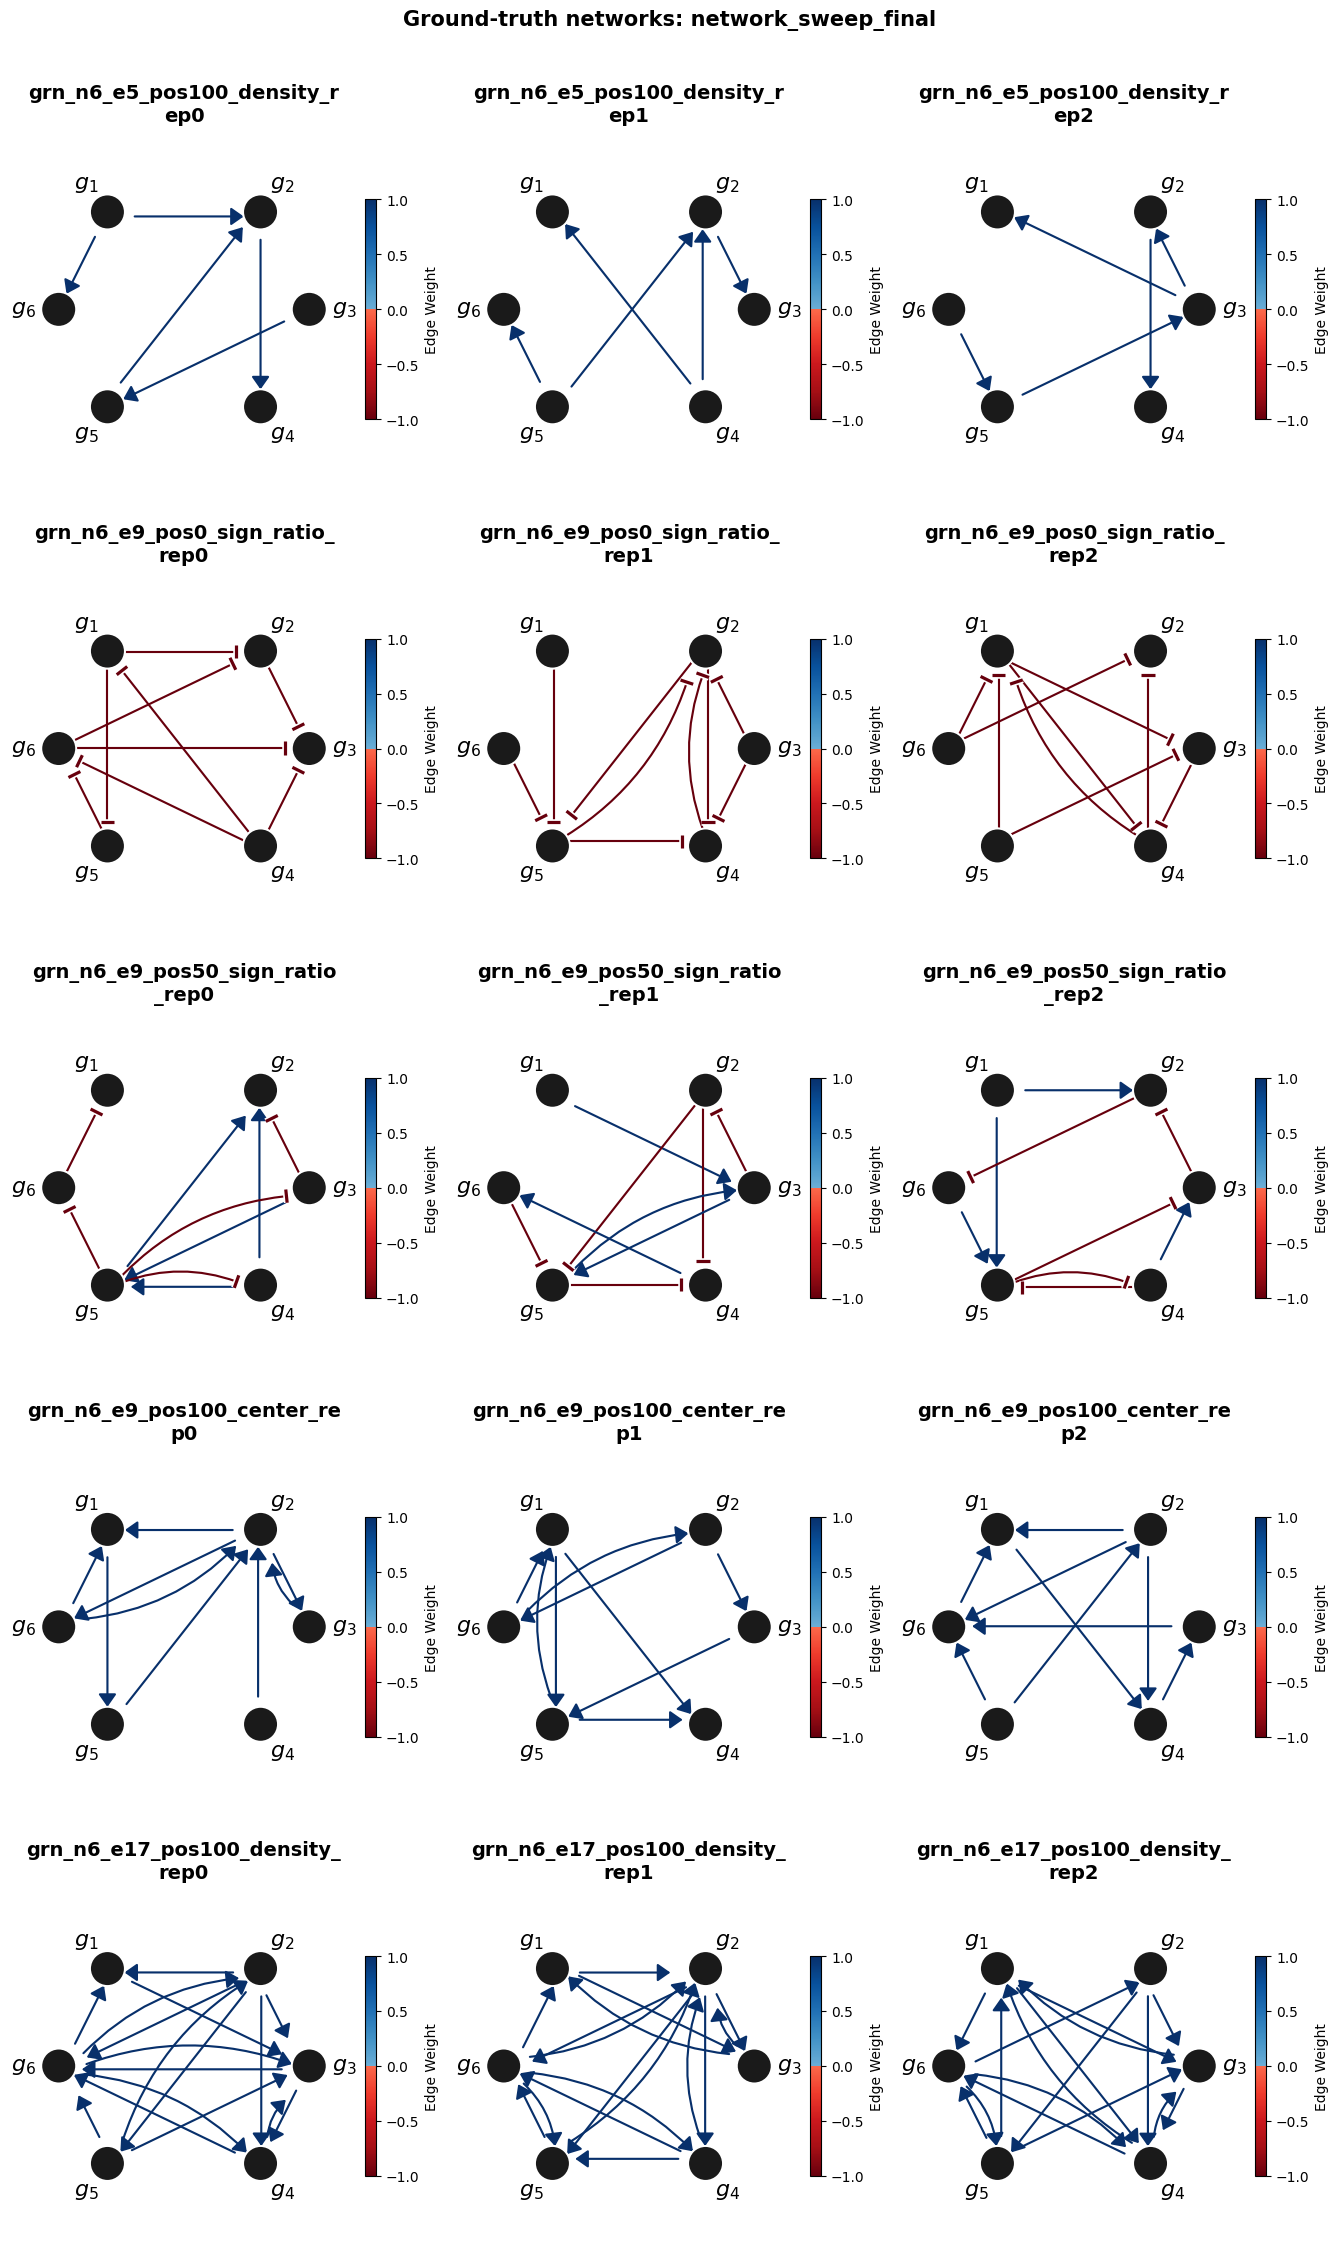

In [5]:
# ---------------------------------------------------------------------------
# 3. Plot every ground-truth network
# ---------------------------------------------------------------------------

ncols = 3
nrows = -(-len(names) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 4.5 * nrows))
axes = np.atleast_2d(axes)

for i, name in enumerate(names):
    r, c = divmod(i, ncols)
    wrapped_title = "\n".join(textwrap.wrap(name, 26))
    plot_grn(
        load_ground_truth(name),
        node_labels=node_labels,
        title=wrapped_title,
        ax=axes[r, c],
        fixed_pos=fixed_pos,
        vmin=-1,
        vmax=1,
    )

for j in range(len(names), nrows * ncols):
    r, c = divmod(j, ncols)
    axes[r, c].axis("off")

fig.suptitle(
    "Ground-truth networks: network_sweep_final",
    fontsize=15, fontweight="bold", y=1.005,
)
fig.tight_layout()
plt.show()
